In [16]:
from pathlib import Path
import json
import numpy as np
import cv2
import shutil
from tqdm import tqdm

# =========================
# 1. CONFIG
# =========================

IMAGES_DIR = Path(
    "/Users/williamtsai/Desktop/nail_unusable_classifier/dataset/usable"
)

JSON_DIR = Path(
    "/Users/williamtsai/Desktop/nail_unusable_classifier/dataset/usable"
)

OUT_DIR = Path(
    "/Users/williamtsai/Desktop/nail_unusable_classifier/dataset/usable_nail_only_png"
)

MASK_DIR = Path(
    "/Users/williamtsai/Desktop/nail_unusable_classifier/dataset/usable_nail_only_masks"
)

TARGET_LABELS = {"nail"}
EXCLUDE_LABELS = {"free_edge", "freeedge", "free-edge"}

DILATE_EXCLUDE_PX = 0
SAVE_MASKS = True
KEEP_ORIGINAL_BG = False
MIN_PIXELS = 50

# Clean output
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
if MASK_DIR.exists():
    shutil.rmtree(MASK_DIR)

OUT_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("JSON_DIR exists  :", JSON_DIR.exists())
print("OUT_DIR          :", OUT_DIR)

if not IMAGES_DIR.exists():
    raise FileNotFoundError(IMAGES_DIR)
if not JSON_DIR.exists():
    raise FileNotFoundError(JSON_DIR)

# =========================
# 2. HELPERS
# =========================

def normalize_label(label):
    return str(label).lower().strip().replace(" ", "_")


def is_valid_path(p: Path):
    s = str(p).lower()
    if "__macosx" in s:
        return False
    if p.name.startswith("._"):
        return False
    if "thumb" in s:
        return False
    return True


def find_image_for_json(json_path: Path, images_dir: Path):
    """
    Match JSON filename stem to image.
    Supports jpg/jpeg/png.
    Searches recursively.
    """
    stem = json_path.stem
    exts = [".png", ".jpg", ".jpeg", ".PNG", ".JPG", ".JPEG"]

    # first try same folder
    for ext in exts:
        cand = json_path.with_suffix(ext)
        if cand.exists() and is_valid_path(cand):
            return cand

    # then search image folder recursively
    for ext in exts:
        matches = [
            p for p in images_dir.rglob(f"{stem}{ext}")
            if p.is_file() and is_valid_path(p)
        ]
        if matches:
            return matches[0]

    return None


def polygon_to_mask(shape_points, h, w):
    pts = np.array(shape_points, dtype=np.float32)
    pts = np.round(pts).astype(np.int32)

    if len(pts) < 3:
        return np.zeros((h, w), dtype=np.uint8)

    pts[:, 0] = np.clip(pts[:, 0], 0, w - 1)
    pts[:, 1] = np.clip(pts[:, 1], 0, h - 1)

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask


def tight_bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    return int(x0), int(y0), int(x1), int(y1)


def apply_mask_and_crop(img_bgr, mask01):
    bbox = tight_bbox_from_mask(mask01)

    if bbox is None:
        return None, None, None

    x0, y0, x1, y1 = bbox
    m255 = (mask01.astype(np.uint8) * 255)

    if KEEP_ORIGINAL_BG:
        masked = img_bgr.copy()
        masked[mask01 == 0] = 0
    else:
        masked = cv2.bitwise_and(img_bgr, img_bgr, mask=m255)

    crop = masked[y0:y1 + 1, x0:x1 + 1]
    crop_mask = m255[y0:y1 + 1, x0:x1 + 1]

    return crop, crop_mask, bbox


# =========================
# 3. PROCESS JSON FILES
# =========================

json_files = sorted([
    p for p in JSON_DIR.rglob("*.json")
    if p.is_file() and is_valid_path(p)
])

print("Found JSON:", len(json_files))

exported = 0
missing_images = 0
skipped_no_label = 0
skipped_tiny = 0
failed = []

for jp in tqdm(json_files):
    img_path = find_image_for_json(jp, IMAGES_DIR)

    if img_path is None:
        missing_images += 1
        continue

    try:
        data = json.loads(jp.read_text(encoding="utf-8"))

        img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            missing_images += 1
            continue

        h, w = img_bgr.shape[:2]

        shapes = data.get("shapes", [])

        nail_shapes = [
            s for s in shapes
            if normalize_label(s.get("label", "")) in TARGET_LABELS
            and len(s.get("points", [])) >= 3
        ]

        exclude_shapes = [
            s for s in shapes
            if normalize_label(s.get("label", "")) in EXCLUDE_LABELS
            and len(s.get("points", [])) >= 3
        ]

        if not nail_shapes:
            skipped_no_label += 1
            continue

        # Build combined free_edge mask
        exclude_mask = np.zeros((h, w), dtype=np.uint8)

        for s in exclude_shapes:
            exclude_mask |= polygon_to_mask(s["points"], h, w)

        if DILATE_EXCLUDE_PX > 0 and exclude_mask.any():
            ksz = 2 * DILATE_EXCLUDE_PX + 1
            kernel = np.ones((ksz, ksz), np.uint8)
            exclude_mask = cv2.dilate(exclude_mask, kernel, iterations=1)

        # Export one crop per nail polygon
        for k, s in enumerate(nail_shapes, start=1):
            nail_mask = polygon_to_mask(s["points"], h, w)

            # nail minus free_edge
            final_mask = (nail_mask & (exclude_mask == 0)).astype(np.uint8)

            if int(final_mask.sum()) < MIN_PIXELS:
                skipped_tiny += 1
                continue

            crop_bgr, crop_mask, bbox = apply_mask_and_crop(img_bgr, final_mask)

            if crop_bgr is None:
                skipped_tiny += 1
                continue

            # If one image has multiple nail polygons, keep multiple outputs
            if len(nail_shapes) == 1:
                out_name = f"{jp.stem}.png"
                mask_name = f"{jp.stem}_mask.png"
            else:
                out_name = f"{jp.stem}_nail_{k:02d}.png"
                mask_name = f"{jp.stem}_nail_{k:02d}_mask.png"

            out_img = OUT_DIR / out_name
            cv2.imwrite(str(out_img), crop_bgr)

            if SAVE_MASKS:
                out_m = MASK_DIR / mask_name
                cv2.imwrite(str(out_m), crop_mask)

            exported += 1

    except Exception as e:
        failed.append((str(jp), str(e)))

print("\nDone.")
print("JSON files       :", len(json_files))
print("exported crops   :", exported)
print("missing_images   :", missing_images)
print("skipped_no_label :", skipped_no_label)
print("skipped_tiny     :", skipped_tiny)
print("failed           :", len(failed))
print("OUT_DIR          :", OUT_DIR)
print("MASK_DIR         :", MASK_DIR)

if failed:
    print("\nFirst failed:")
    for name, err in failed[:10]:
        print(name, "->", err)

IMAGES_DIR exists: True
JSON_DIR exists  : True
OUT_DIR          : /Users/williamtsai/Desktop/nail_unusable_classifier/dataset/usable_nail_only_png
Found JSON: 848


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 848/848 [02:11<00:00,  6.45it/s]


Done.
JSON files       : 848
exported crops   : 3508
missing_images   : 0
skipped_no_label : 0
skipped_tiny     : 1
failed           : 0
OUT_DIR          : /Users/williamtsai/Desktop/nail_unusable_classifier/dataset/usable_nail_only_png
MASK_DIR         : /Users/williamtsai/Desktop/nail_unusable_classifier/dataset/usable_nail_only_masks


Total crops on disk: 3508


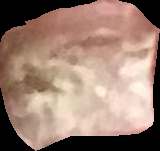

20221201094810_pid2625_o72gkm_nail_02.png


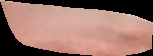

20221207093831_pid2625_pV4kCz_nail_04.png


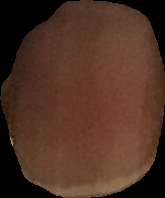

20211005173559_pid2625_ipx5ey_nail_02.png


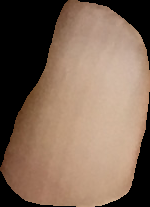

20230502122658_pid2625_i8rktj_nail_03.png


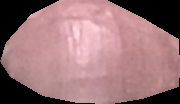

20220124161240_pid2625_yMYanT_nail_04.png


In [17]:
from pathlib import Path
from PIL import Image
from IPython.display import display
import random

crops = sorted(OUT_DIR.glob("*.png"))
print("Total crops on disk:", len(crops))

for p in random.sample(crops, min(5, len(crops))):
    display(Image.open(p))
    print(p.name)